In [19]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Custom functions (assumed in your local directory)
from fix_grid import fix_grid 
from useful_calculations import weighted_means

In [20]:
# Paths for filtered datasets and plots
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'


In [21]:
# Load MOM5 control dataset
ds_mom=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_monthly_0181-0190_noice_all.nc')
#dscc=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_1PctTo2X_monthly_0181-0190_noice_all.nc')

In [22]:
###MEAN FILTER
#pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
#pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
#dsa=xr.open_dataset(pathf+'3x3box_mean_anomaly_monthly_0181-0190_all.nc', chunks='auto')
#ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_control_noice.nc', chunks='auto')
#ds_cc=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_1PctTo2X_noice.nc', chunks='auto')
#ds_smoothed=xr.open_dataset(pathf+'3x3box_mean_monthly_0181-0190_noice_all.nc')

###MEDIAN FILTER

# Paths for filtered datasets and plots
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'

# Load median filtered datasets (mesoscale anomalies)
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc')
ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_control_noice.nc', chunks='auto')
# Apply grid fixes
dsa=fix_grid(dsa)
ds=fix_grid(ds)
grid=xr.open_dataset(pathf+'ocean_grid.nc')

# Compute absolute mean fluxes over time for anomalies
co2=abs(dsa.dic_stf)
o2=abs(dsa.o2_stf)
co2_cc=abs(dsa.dic_stf_1PctTo2X)
o2_cc=abs(dsa.o2_stf_1PctTo2X)

combined_mask_ctrl=xr.open_dataset(pathf+'categorization_simple.nc').corr_o2_stf_dic_stf
combined_mask_cc=xr.open_dataset(pathf+'categorization_simple_1PctTo2X.nc').corr_o2_stf_dic_stf_1PctTo2X

#co2=co2.mean(dim='time')
#o2=o2.mean(dim='time')

#dif=co2/o2

# Calculate zonal means for total fluxes
#dic_xmean=ds.dic_stf_mean.mean(dim='xt_ocean')
#o2_xmean=ds.o2_stf_mean.mean(dim='xt_ocean')

# Flux ratios (mesoscale/total)
#ratio_co2=co2.mean(dim='xt_ocean')/abs(dic_xmean)
#ratio_o2=o2.mean(dim='xt_ocean')/abs(o2_xmean)

In [ ]:
###don't run again, use the next cell instead
ds_var=ds_mom[['o2_stf', 'dic_stf', 'o2_stf_1PctTo2X', 'dic_stf_1PctTo2X']].var(dim='time')
dsa_var=dsa[['o2_stf', 'dic_stf', 'o2_stf_1PctTo2X', 'dic_stf_1PctTo2X']].var(dim='time')
dsa_var.to_netcdf(pathf+'variance_anomaly.nc')
ds_var.to_netcdf(pathf+'variance_total.nc')


In [23]:
# run this if the data was already calculated and saved in the previous cell
dsa_var=xr.open_dataset(pathf+'variance_anomaly.nc')
ds_var=xr.open_dataset(pathf+'variance_total.nc')

In [24]:
dsa_var=fix_grid(dsa_var)
ds_var=fix_grid(ds_var)

In [39]:
(dsa_var/ds_var).where(ds_var>=dsa_var).weighted(grid.area_t.fillna(0)).mean().values

<bound method Mapping.values of <xarray.Dataset>
Dimensions:           ()
Coordinates:
    st_ocean          float64 5.034
Data variables:
    o2_stf            float32 0.07481
    dic_stf           float32 0.07284
    o2_stf_1PctTo2X   float32 0.07087
    dic_stf_1PctTo2X  float32 0.06697>

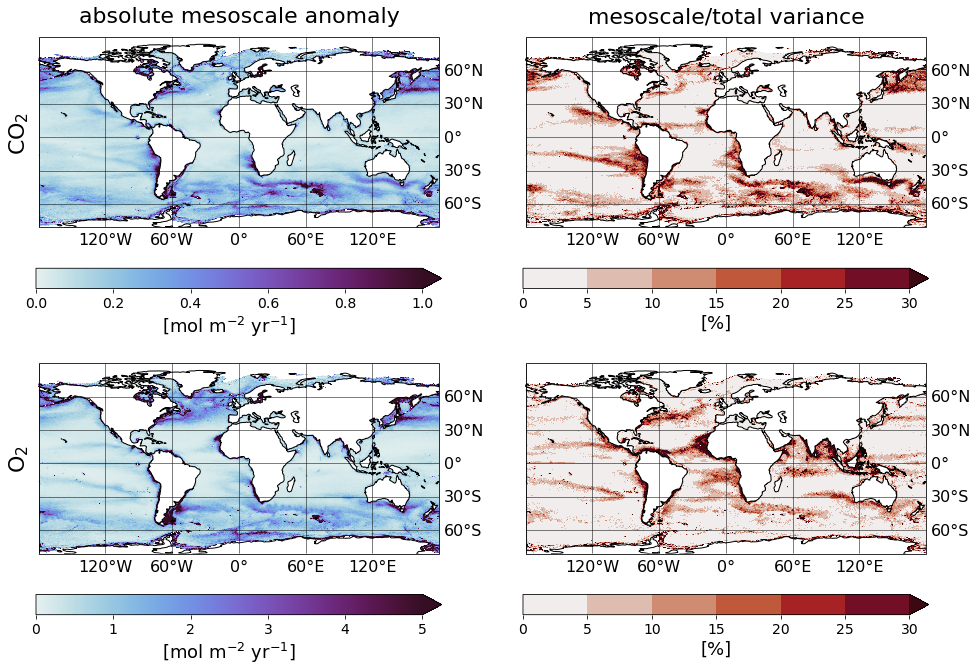

In [24]:
co2_mean=co2.mean('time')
o2_mean=o2.mean('time')


fig, axs= plt.subplots(nrows=2, ncols=2 , figsize=(16,11),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)
axs=axs.flatten()
levels=np.linspace(0,30,7)
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

co2_mean.plot(ax=axs[0], x='geolon_t', y='geolat_t',vmin=0, vmax=1, cmap=cmo.dense, transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})
#dsa_var.dic_stf.plot(ax=axs[1], vmin=0, vmax=2, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[mol$^{2} $m$^{-4}$ yr$^{-2}$]", 'extend':'max'})
((dsa_var.dic_stf/ds_var.dic_stf)*100).plot(ax=axs[1], levels=levels, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[%]", 'extend':'max', 'ticks':levels})

o2_mean.plot(ax=axs[2], x='geolon_t', y='geolat_t',vmin=0, vmax=5, cmap=cmo.dense, transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
#dsa_var.o2_stf.plot(ax=axs[4], vmin=0, vmax=40, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[mol$^{2} $m$^{-4}$ yr$^{-2}$]", 'extend':'max'})
((dsa_var.o2_stf/ds_var.o2_stf)*100).plot(ax=axs[3], levels=levels, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal','label': "[%]", 'extend':'max', 'ticks':levels})


for i in range(4):
    gl = axs[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='black', alpha=0.5)
    gl.xlabels_top = False
    gl.ylabels_left = False
    axs[i].coastlines()

axs[0].set_title('absolute mesoscale anomaly', fontsize=22, pad=15);
#axs[1].set_title('mesoscale variance', fontsize=22, pad=15);
axs[1].set_title('mesoscale/total variance', fontsize=22, pad=15);
axs[2].set_title('');
axs[3].set_title('');
#axs[5].set_title('');


top_y = (axs[0].get_position().y0 + axs[0].get_position().y1)/2
bottom_y = (axs[3].get_position().y0 + axs[3].get_position().y1)/2

fig.text(0.1, top_y, 'CO$_2$', rotation=90,
         fontsize=22, va='center')

fig.text(0.1, bottom_y, 'O$_2$', rotation=90,
         fontsize=22, va='center')

plt.savefig(pathp+'mesoscale_contribution.png', dpi=300, bbox_inches='tight');

In [25]:
co2_mean=co2.mean('time')
o2_mean=o2.mean('time')
co2_mean_cc=co2_cc.mean('time')
o2_mean_cc=o2_cc.mean('time')

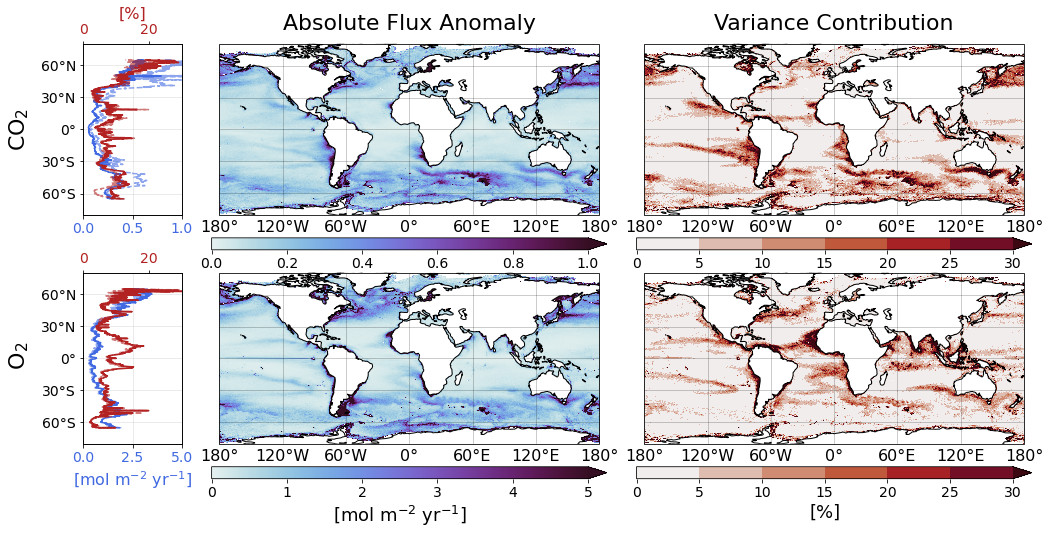

In [26]:

levels=np.linspace(0,30,7)

fig = plt.figure(figsize=(17,8), layout='compressed')

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

gs = gridspec.GridSpec(
    4, 3,
    width_ratios=[1, 4, 4],
    height_ratios=[1, 0.07, 1, 0.07],   # last row for colorbars
    wspace=0.1,
    hspace=0.25
)

ax_zm1 = fig.add_subplot(gs[0, 0])
ax_zm2 = fig.add_subplot(gs[2, 0])

cax1 = fig.add_subplot(gs[1,1])
cax2 = fig.add_subplot(gs[1,2])
cax3 = fig.add_subplot(gs[3,1])
cax4 = fig.add_subplot(gs[3,2])

ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.ylabels_right= False

    ax.coastlines()

im1=co2_mean.plot(ax=ax1, x='geolon_t', y='geolat_t',vmin=0, vmax=1, cmap=cmo.dense, transform=ccrs.PlateCarree(), add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})
co2_contr=((dsa_var.dic_stf/ds_var.dic_stf)*100)
co2_contr_cc=((dsa_var.dic_stf_1PctTo2X/ds_var.dic_stf_1PctTo2X)*100)
im2=co2_contr.plot(ax=ax2, levels=levels, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(), add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[%]", 'extend':'max', 'ticks':levels})

im3=o2_mean.plot(ax=ax3, x='geolon_t', y='geolat_t',vmin=0, vmax=5, cmap=cmo.dense, transform=ccrs.PlateCarree(),add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})
o2_contr=((dsa_var.o2_stf/ds_var.o2_stf)*100)
o2_contr_cc=((dsa_var.o2_stf_1PctTo2X/ds_var.o2_stf_1PctTo2X)*100)
im4=o2_contr.plot(ax=ax4, levels=levels, x='geolon_t', y='geolat_t', cmap=cmo.amp, transform = ccrs.PlateCarree(), add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[%]", 'extend':'max', 'ticks':levels})


##colorbars
cb1 = fig.colorbar(im1, cax=cax1, orientation='horizontal', extend='max')
cb1.set_label("[mol m$^{-2}$ yr$^{-1}$]")

cb2 = fig.colorbar(im2, cax=cax2, orientation='horizontal', extend='max')
cb2.set_label("[%]")

cb3 = fig.colorbar(im3, cax=cax3, orientation='horizontal', extend='max')
cb3.set_label("[mol m$^{-2}$ yr$^{-1}$]")

cb4 = fig.colorbar(im4, cax=cax4, orientation='horizontal', extend='max')
cb4.set_label("[%]")

#zonal means
co2_zm = co2_mean.mean('xt_ocean')
co2_zm_cc = co2_mean_cc.mean('xt_ocean')
co2_con_zm = co2_contr.mean('xt_ocean')
co2_con_zm_cc = co2_contr_cc.mean('xt_ocean')


o2_zm = o2_mean.mean('xt_ocean')
o2_zm_cc = o2_mean_cc.mean('xt_ocean')
o2_con_zm = o2_contr.mean('xt_ocean')
o2_con_zm_cc = o2_contr_cc.mean('xt_ocean')


lat_true = ds.geolat_t.where(ds.geolat_t<=90).mean(dim='xt_ocean')
co2_zm = co2_zm.assign_coords(yt_ocean=lat_true)
co2_zm_cc = co2_zm_cc.assign_coords(yt_ocean=lat_true)
co2_con_zm = co2_con_zm.assign_coords(yt_ocean=lat_true)
co2_con_zm_cc = co2_con_zm_cc.assign_coords(yt_ocean=lat_true)


o2_zm = o2_zm.assign_coords(yt_ocean=lat_true)
o2_zm_cc = o2_zm_cc.assign_coords(yt_ocean=lat_true)
o2_con_zm = o2_con_zm.assign_coords(yt_ocean=lat_true)
o2_con_zm_cc = o2_con_zm_cc.assign_coords(yt_ocean=lat_true)


co2_zm=co2_zm.where((co2_zm.yt_ocean<=65) & (co2_zm.yt_ocean >=-65))
co2_zm_cc=co2_zm_cc.where((co2_zm_cc.yt_ocean<=65) & (co2_zm_cc.yt_ocean >=-65))
co2_con_zm=co2_con_zm.where((co2_con_zm.yt_ocean<=65) & (co2_con_zm.yt_ocean >=-65))
co2_con_zm_cc=co2_con_zm_cc.where((co2_con_zm_cc.yt_ocean<=65) & (co2_con_zm_cc.yt_ocean >=-65))


o2_zm=o2_zm.where((o2_zm.yt_ocean<=65) & (o2_zm.yt_ocean >=-65))
o2_zm_cc=o2_zm_cc.where((o2_zm_cc.yt_ocean<=65) & (o2_zm_cc.yt_ocean >=-65))
o2_con_zm=o2_con_zm.where((o2_con_zm.yt_ocean<=65) & (o2_con_zm.yt_ocean >=-65))
o2_con_zm_cc=o2_con_zm_cc.where((o2_con_zm_cc.yt_ocean<=65) & (o2_con_zm_cc.yt_ocean >=-65))

ax_zm1.plot(co2_zm, co2_zm.yt_ocean, c='royalblue')
ax_zm1.plot(co2_zm_cc, co2_zm_cc.yt_ocean, c='royalblue', linestyle='--', alpha=0.6)

ax_zm1_1 = ax_zm1.twiny()  
ax_zm1_1.plot(co2_con_zm, co2_con_zm.yt_ocean, c='firebrick')
ax_zm1_1.plot(co2_con_zm_cc, co2_con_zm_cc.yt_ocean, c='firebrick', linestyle='--', alpha=0.6)

ax_zm2.plot(o2_zm, o2_zm.yt_ocean, c='royalblue')
ax_zm2.plot(o2_zm_cc, o2_zm_cc.yt_ocean, c='royalblue', linestyle='--', alpha=0.6)
ax_zm2_1 = ax_zm2.twiny() 
ax_zm2_1.plot(o2_con_zm, o2_con_zm.yt_ocean, c='firebrick')
ax_zm2_1.plot(o2_con_zm_cc, o2_con_zm_cc.yt_ocean, c='firebrick', linestyle='--', alpha=0.6)

ax_zm1.tick_params(axis='x', labelcolor='royalblue')
ax_zm2.tick_params(axis='x', labelcolor='royalblue')

ax_zm1_1.tick_params(axis='x', labelcolor='firebrick')
ax_zm2_1.tick_params(axis='x', labelcolor='firebrick')

ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1, ax_zm2]:
    ax.set_ylim(-80, 80)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

for ax in [ax3,ax4]:
    ax.set_title('')

ax1.set_title('Absolute Flux Anomaly', y=1.05)
ax2.set_title('Variance Contribution', y=1.05)
#ax_zm1.set_title('zonal mean', y=1.05)

ax_zm1_1.set_xlabel('[%]', fontsize=16, color='firebrick')
#ax_zm1.set_xlabel('[mol m$^{-2}$ yr$^{-1}$]', fontsize=16, color='royalblue')
ax_zm1_1.set_xlim([0,30])
ax_zm2_1.set_xlim([0,30])
ax_zm1.set_xlim([0,1])
ax_zm2.set_xlim([0,5])
#ax_zm2_1.set_xlabel('[%]', fontsize=16, color='firebrick')
ax_zm2.set_xlabel('[mol m$^{-2}$ yr$^{-1}$]', fontsize=16, color='royalblue')
ax_zm1.set_ylabel("CO$_2$", fontsize=22, labelpad=10)
ax_zm2.set_ylabel(" O$_2$", fontsize=22, labelpad=10)
plt.savefig(pathp+'mesoscale_contribution_zm.png', dpi=300, bbox_inches='tight');

# Heat fluxes

In [6]:
corr  =xr.open_dataset(pathf+'3x3box_median_corr_monthly_0181-0190_all.nc', chunks='auto')

In [10]:
weights=grid.area_t.fillna(0)

In [13]:
corr['corr_sst_sens_heat'].weighted(weights).mean().values

array(-0.80224591)

In [40]:
#zonal means
evap_zm1 = corr['corr_sst_evap_heat'].mean('xt_ocean')
sens_zm1=corr['corr_sst_sens_heat'].mean('xt_ocean')
lat_true = corr.geolat_t.where(corr.geolat_t<=90).mean(dim='xt_ocean')
evap_zm2 = evap_zm1.assign_coords(yt_ocean=lat_true)
sens_zm2 = sens_zm1.assign_coords(yt_ocean=lat_true)

evap_zm3=evap_zm2.where((evap_zm2.yt_ocean<=65) & (evap_zm2.yt_ocean >=-65))
sens_zm3=sens_zm2.where((sens_zm2.yt_ocean<=65) & (sens_zm2.yt_ocean >=-65))

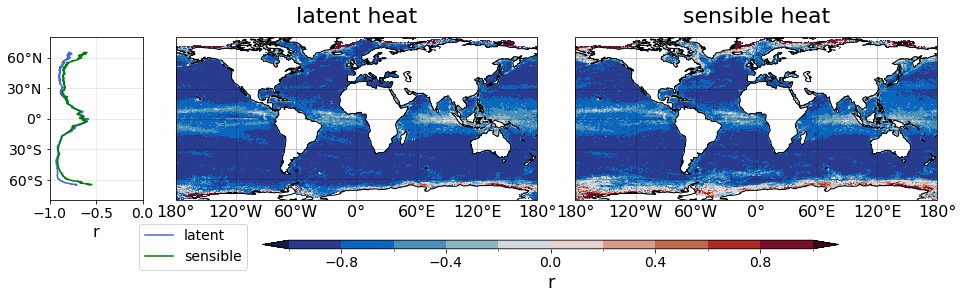

In [41]:
levels=np.linspace(-1,1,11)

fig = plt.figure(figsize=(16,3), layout='compressed')

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1, 4, 4],
    height_ratios=[1],   # last row for colorbars
    wspace=0.1,
    hspace=0.25
)

ax_zm1 = fig.add_subplot(gs[0, 0])

ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.ylabels_right= False

    ax.coastlines()

im1=corr['corr_sst_evap_heat'].plot.contourf(ax=ax1, x='geolon_t', y='geolat_t',vmin=-1, vmax=1, levels=levels, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})
im3=corr['corr_sst_sens_heat'].plot.contourf(ax=ax2, x='geolon_t', y='geolat_t',vmin=-1, vmax=1, levels=levels, cmap=cmo.balance, transform=ccrs.PlateCarree(),add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

cbar_ax = fig.add_axes([0.31, -0.1, 0.5, 0.04])
cb = fig.colorbar(im3, cax=cbar_ax,orientation='horizontal');
cb.ax.tick_params(labelsize=14)
cb.set_label('r')

#zonal means

ax_zm1.plot(evap_zm3, evap_zm3.yt_ocean, c='royalblue', label='latent')
ax_zm1.plot(sens_zm3, sens_zm3.yt_ocean, c='green', label='sensible')
#

ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1]:
    ax.set_ylim(-80, 80)
    ax.grid(alpha=0.3)
    ax.set_xlim(-1,0)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

ax1.set_title('latent heat', y=1.05)
ax2.set_title('sensible heat', y=1.05)
#ax_zm2_1.set_xlabel('[%]', fontsize=16, color='firebrick')
ax_zm1.set_xlabel('r', fontsize=16)
ax_zm1.legend(bbox_to_anchor=(0, 0, 2.2, -.1), fontsize=14)
plt.savefig(pathp+'heat_fluxes_si.png', dpi=300, bbox_inches='tight');

# wind corr

In [7]:
dsa_wind=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_wind.nc').wind_stress
ssta=dsa.SST

In [25]:
wind_sst_corr=xr.corr(dsa_wind, ssta, dim='time').compute()

In [26]:
wind_sst_corr_zm=wind_sst_corr.mean(dim='xt_ocean').compute()
lat_true = wind_sst_corr.geolat_c.where(wind_sst_corr.geolat_c<=90).mean(dim='xt_ocean')
wind_sst_corr_zm = wind_sst_corr_zm.assign_coords(yt_ocean=lat_true)
wind_sst_corr_zm=wind_sst_corr_zm.where((wind_sst_corr_zm.yt_ocean<=65) & (wind_sst_corr_zm.yt_ocean >=-65))

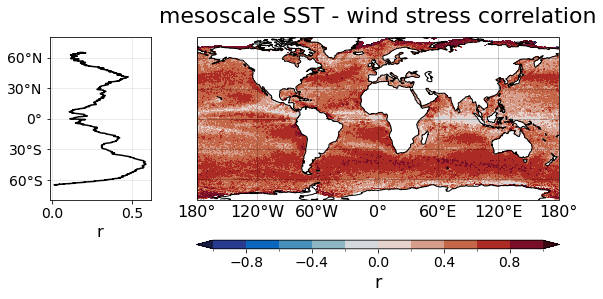

In [38]:
levels=np.linspace(-1,1,11)

fig = plt.figure(figsize=(9.5,3), layout='compressed')

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[1, 4],
    height_ratios=[1],   # last row for colorbars
    wspace=0.1,
    hspace=0.25
)

ax_zm1 = fig.add_subplot(gs[0, 0])

ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
#ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

for ax in [ax1]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.ylabels_right= False

    ax.coastlines()

im1=wind_sst_corr.plot.contourf(ax=ax1, x='geolon_c', y='geolat_c',vmin=-1, vmax=1, levels=levels, cmap=cmo.balance, transform=ccrs.PlateCarree(), add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})
#im3=corr['corr_sst_sens_heat'].plot.contourf(ax=ax2, x='geolon_t', y='geolat_t',vmin=-1, vmax=1, levels=levels, cmap=cmo.balance, transform=ccrs.PlateCarree(),add_colorbar=False)#,cbar_kwargs={'orientation':'horizontal','label': "[mol m$^{-2}$ yr$^{-1}$]",'extend':'max'})#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

cbar_ax = fig.add_axes([0.34, -0.1, 0.53, 0.04])
cb = fig.colorbar(im1, cax=cbar_ax,orientation='horizontal');
cb.ax.tick_params(labelsize=14)
cb.set_label('r')


#zonal means

ax_zm1.plot(wind_sst_corr_zm, wind_sst_corr_zm.yt_ocean, c='black', label='latent')

ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1]:
    ax.set_ylim(-80, 80)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

ax1.set_title('mesoscale SST - wind stress correlation', y=1.05)
#ax2.set_title('sensible heat', y=1.05)
#ax_zm2_1.set_xlabel('[%]', fontsize=16, color='firebrick')
ax_zm1.set_xlabel('r', fontsize=16)
#ax_zm1.legend(bbox_to_anchor=(0, 0, 2.2, -.1), fontsize=14)
plt.savefig(pathp+'wind_corr_si.png', dpi=300, bbox_inches='tight');

# Regional contribution

In [10]:
# Define your drivers
drivers = {
    1: 'solubility',
    2: 'productivity',
    3: 'respiration'
}

# Masks for control and CC
masks = {
    'Ctrl': combined_mask_ctrl,
    'CC': combined_mask_cc
}

# Dictionary to store area fractions
area_fractions = {}
area_complete={}

for scenario, mask in masks.items():
    # Calculate total area for this scenario
    total_area = sum(grid.area_t.where(mask == driver).sum() for driver in drivers)
    
    # Store fractions
    area_fractions[scenario] = {}
    area_complete[scenario] = {}
    for driver_val, driver_name in drivers.items():
        area = grid.area_t.where(mask == driver_val).sum()
        fraction = (area / total_area).values  # fraction as a number
        area_fractions[scenario][driver_name] = fraction
        area_complete[scenario][driver_name] = area.values
        print(f'{fraction:.3f}', scenario, driver_name)

# Example: access Sol fraction in CC scenario
# area_fractions['CC']['Sol']

0.511 Ctrl solubility
0.288 Ctrl productivity
0.201 Ctrl respiration
0.603 CC solubility
0.270 CC productivity
0.127 CC respiration


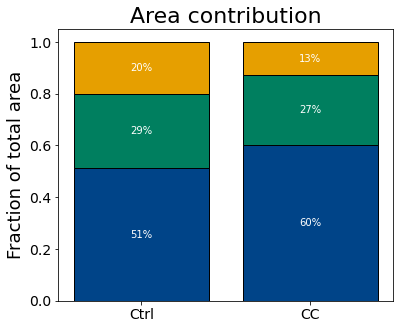

In [11]:
drivers_order = ['solubility', 'productivity', 'respiration']
colors = ["#004488","#007F5F","#e69f00"]

# Define the order of scenarios for the x-axis
scenarios = ['Ctrl', 'CC']

fig, ax = plt.subplots(figsize=(6,5))

for i, scenario in enumerate(scenarios):
    bottom = 0
    total = sum(area_fractions[scenario].values())  # should be 1
    for driver, color in zip(drivers_order, colors):
        fraction = area_fractions[scenario][driver]
        ax.bar(i, fraction, bottom=bottom, color=color, edgecolor='k')
        
        # Add percentage text inside segment
        if fraction > 0.02:  # skip very small fractions
            ax.text(
                i,
                bottom + fraction/2,
                f'{fraction*100:.0f}%',
                ha='center', va='center', color='white', fontsize=10
            )
        bottom += fraction

# Customize axes
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels(scenarios)
ax.set_ylabel('Fraction of total area')
ax.set_title('Area contribution')
#ax.legend(drivers_order, title='Driver')

plt.savefig(pathp+'Area_bars.png', dpi=300, bbox_inches='tight');

In [28]:
def sum_mesoflux(data, filter):
    data_mean=data.mean(dim='time')
    data_mean=data_mean.where(filter)
    data_sum=(grid.area_t*data_mean).sum()
    return data_sum

In [29]:
# Drivers and masks
drivers = {1:'solubility', 2:'productivity', 3:'respiration'}
masks = {
    'Ctrl': combined_mask_ctrl,
    'CC': combined_mask_cc
}

# Variables
variables = {
    'CO2 Ctrl': co2,
    'CO2 CC': co2_cc,
    'O2 Ctrl': o2,
    'O2 CC': o2_cc
}

colors = ["#004488","#007F5F","#e69f00"]

# Calculate total flux per driver per variable
total_flux = {}
for var_name, data in variables.items():
    # Determine scenario from var_name
    scenario = 'Ctrl' if 'Ctrl' in var_name else 'CC'
    mask = masks[scenario]
    
    total_flux[var_name] = {}
    for driver_val, driver_name in drivers.items():
        flux = sum_mesoflux(data, filter=(mask == driver_val))
        total_flux[var_name][driver_name] = flux.values

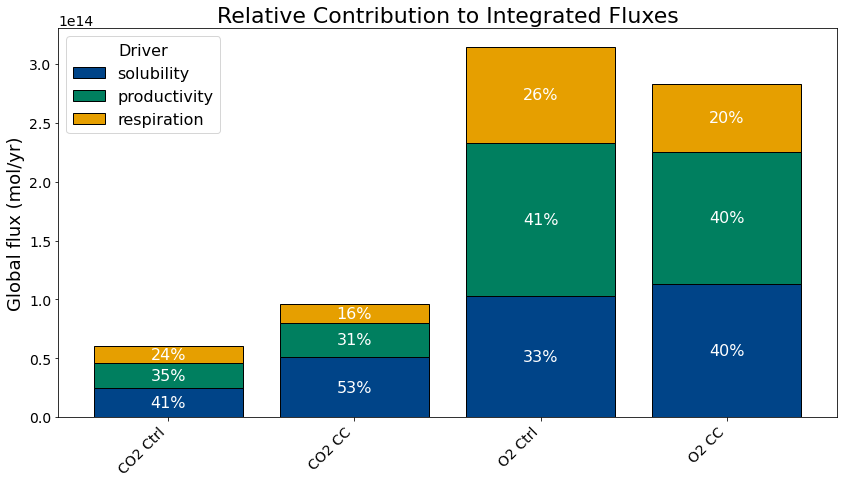

In [31]:
fig, ax = plt.subplots(figsize=(12,7))
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

for i, var_name in enumerate(variables):
    bottom = 0
    total = sum(total_flux[var_name].values())
    
    for driver_name, color in zip(drivers.values(), colors):
        flux = total_flux[var_name][driver_name]
        ax.bar(i, flux, bottom=bottom, color=color, edgecolor='k')
        
        # Percentage label inside the segment
        fraction = flux / total
        if fraction > 0.02:  # skip tiny segments
            ax.text(
                i,
                bottom + flux/2,
                f'{fraction*100:.0f}%',
                ha='center', va='center', color='white'
            )
        bottom += flux

# Axes and legend
ax.set_xticks(range(len(variables)))
ax.set_xticklabels(variables.keys(), rotation=45, ha='right')
ax.set_ylabel('Global flux (mol/yr)')
ax.set_title('Relative Contribution to Integrated Fluxes', fontsize=22)
ax.legend(drivers.values(), title='Driver')

plt.tight_layout()
plt.savefig(pathp+'Abs_meso_contr_bars.png', dpi=300, bbox_inches='tight');

In [84]:
# flux intensity per driver region

In [32]:
# Your result dict
flux_per_area = {}

for species_key, flux_dict in total_flux.items():
    # Determine scenario: "Ctrl" or "CC"
    scenario = "Ctrl" if "Ctrl" in species_key else "CC"
    
    flux_per_area[species_key] = {}
    
    for process, value in flux_dict.items():
        # Divide by the area fraction
        flux_per_area[species_key][process] = value / area_complete[scenario][process]

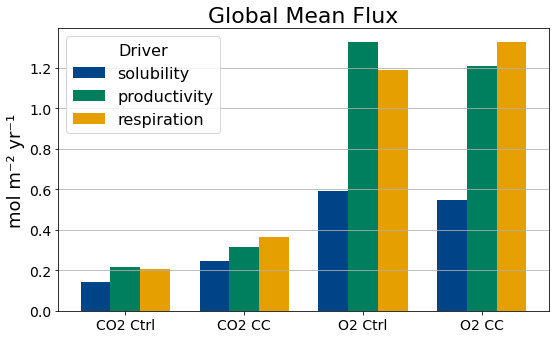

In [33]:
drivers = ['solubility', 'productivity', 'respiration']
labels = ['CO2 Ctrl', 'CO2 CC', 'O2 Ctrl', 'O2 CC']
colors = ["#004488","#007F5F","#e69f00"]

# data: (labels, drivers)
data = np.array([[flux_per_area[label][driver] for driver in drivers] for label in labels])

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))

# loop over drivers (bars within each gas group)
for i, (driver, color) in enumerate(zip(drivers, colors)):
    ax.bar(x + i*width - width, data[:, i], width, label=driver, color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("mol m⁻² yr⁻¹")
ax.set_title("Global Mean Flux")
ax.legend(title="Driver")
ax.grid(axis='y')

plt.tight_layout()
plt.savefig(pathp+'Flux_intensity_bar.png', dpi=300, bbox_inches='tight')

In [14]:
def variance_contribtion_mean(meso,total,mask):
    weights=grid.area_t.where(mask).fillna(0)
    meso=meso.where(mask)
    total=total.where(mask)
    mesowm=meso.weighted(weights).mean()
    totalwm=total.weighted(weights).mean()
    contr=(mesowm/totalwm)*100
    return contr.values

In [25]:
var_list = ['dic_stf', 'o2_stf', 'dic_stf_1PctTo2X', 'o2_stf_1PctTo2X']

results = {}

for var in var_list:
    if '1PctTo2X' in var:
        mask = combined_mask_cc
    else:
        mask = combined_mask_ctrl

    # initialize dict for this variable
    results[var] = {}

    # total contribution
    results[var]['total'] = variance_contribtion_mean(
        dsa_var[var], ds_var[var], mask > 0
    )

    # contributions by driver
    for i in range(1, 4):
        value = variance_contribtion_mean(
            dsa_var[var], ds_var[var], mask == i
        )

        if i == 1:
            driver = 'solubility'
        elif i == 2:
            driver = 'productivity'
        elif i == 3:
            driver = 'respiration'

        results[var][driver] = value

In [26]:
df = pd.DataFrame(results).T

In [30]:
df.index = ['CO2', 'O2', 'CO2 CC', 'O2 CC']
df = df[['total', 'solubility', 'productivity', 'respiration']]

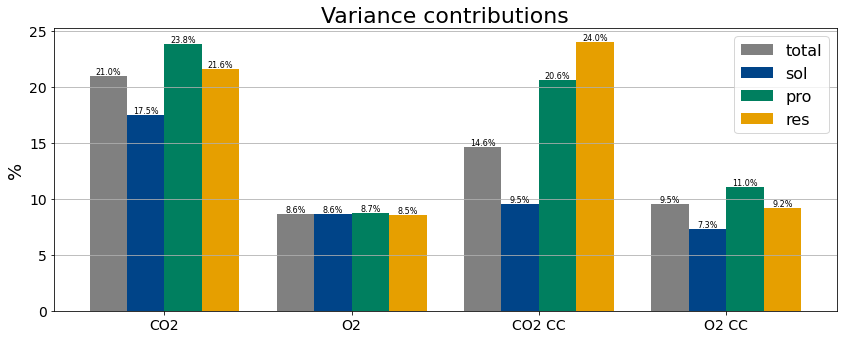

In [44]:
labels = df.index
x = np.arange(len(labels))  # group positions
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12,5))
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

colors = ["#004488","#007F5F","#e69f00"]

bars_total=ax.bar(x - 1.5*width, df['total'], width, color='gray', label='total')
bars_sol=ax.bar(x - 0.5*width, df['solubility'], width, color=colors[0], label='sol')
bars_pro=ax.bar(x + 0.5*width, df['productivity'], width, color=colors[1], label='pro')
bars_res=ax.bar(x + 1.5*width, df['respiration'], width, color=colors[2], label='res')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}%',   # format as percentage
            ha='center',
            va='bottom',
            fontsize=8
        )

# apply to all bars
add_labels(bars_total)
add_labels(bars_sol)
add_labels(bars_pro)
add_labels(bars_res)



ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel('%')
ax.set_title('Variance contributions')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(pathp+'Variance_Contribution_bar.png', dpi=300, bbox_inches='tight');

In [ ]:
###other version

In [57]:
def variance_contribtion_awm(meso,total,mask):
    total_neu=total.where(total>meso)
    meso_neu=meso.where(total>meso)
    contr=(meso_neu/total_neu)*100
    weights=grid.area_t.where(mask).fillna(0)
    contr=contr.where(mask)
    contr_awm=contr.weighted(weights).mean()
    return contr_awm.values

In [61]:
var_list = ['dic_stf', 'o2_stf', 'dic_stf_1PctTo2X', 'o2_stf_1PctTo2X']

results = {}

for var in var_list:
    if '1PctTo2X' in var:
        mask = combined_mask_cc
    else:
        mask = combined_mask_ctrl

    # initialize dict for this variable
    results[var] = {}

    # total contribution
    results[var]['total'] = variance_contribtion_awm(
        dsa_var[var], ds_var[var], mask > 0
    )

    # contributions by driver
    for i in range(1, 4):
        value = variance_contribtion_awm(
            dsa_var[var], ds_var[var], mask == i
        )

        if i == 1:
            driver = 'solubility'
        elif i == 2:
            driver = 'productivity'
        elif i == 3:
            driver = 'respiration'

        results[var][driver] = value

In [62]:
df = pd.DataFrame(results).T
df.index = ['CO2', 'O2', 'CO2 CC', 'O2 CC']
df = df[['total', 'solubility', 'productivity', 'respiration']]

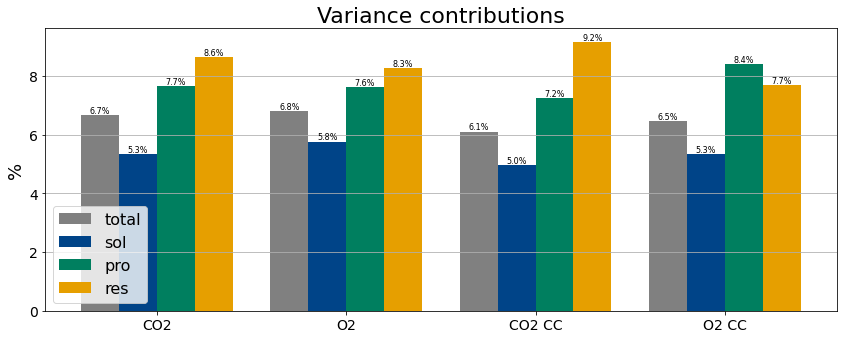

In [66]:
labels = df.index
x = np.arange(len(labels))  # group positions
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12,5))
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

colors = ["#004488","#007F5F","#e69f00"]

bars_total=ax.bar(x - 1.5*width, df['total'], width, color='gray', label='total')
bars_sol=ax.bar(x - 0.5*width, df['solubility'], width, color=colors[0], label='sol')
bars_pro=ax.bar(x + 0.5*width, df['productivity'], width, color=colors[1], label='pro')
bars_res=ax.bar(x + 1.5*width, df['respiration'], width, color=colors[2], label='res')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}%',   # format as percentage
            ha='center',
            va='bottom',
            fontsize=8
        )

# apply to all bars
add_labels(bars_total)
add_labels(bars_sol)
add_labels(bars_pro)
add_labels(bars_res)



ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel('%')
ax.set_title('Variance contributions')
ax.legend(loc='lower left')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(pathp+'Variance_Contribution_bar_awm.png', dpi=300, bbox_inches='tight');

In [16]:
CO2O2=corr.corr_o2_stf_dic_stf

In [24]:
corrsol=CO2O2.where(combined_mask_ctrl==1).weighted(weights).mean()

In [27]:
corrpro=CO2O2.where(combined_mask_ctrl==2).weighted(weights).mean()

In [29]:
corrres=CO2O2.where(combined_mask_ctrl==3).weighted(weights).mean()

In [31]:
corrres.values

array(-0.30805912)

In [33]:
corrsol.values

array(0.28891666)

In [34]:
corrpro.values

array(-0.37086613)

In [35]:
CO2O2_cc=corr.corr_o2_stf_dic_stf_1PctTo2X

In [41]:
corrsol_cc=CO2O2_cc.where(combined_mask_cc==1).weighted(weights).mean()
corrpro_cc=CO2O2_cc.where(combined_mask_cc==2).weighted(weights).mean()
corrres_cc=CO2O2_cc.where(combined_mask_cc==3).weighted(weights).mean()

In [40]:
corrsol_cc.values

array(0.34625545)

In [42]:
corrpro_cc.values

array(-0.33705726)

In [ ]:
corrres_cc.values

# variance cc

In [ ]:
weights=grid.area_t.fillna(0)

In [14]:
dsa_var.o2_stf.weighted(weights).mean().values

array(7.002928, dtype=float32)

In [15]:
dsa_var.o2_stf_1PctTo2X.weighted(weights).mean().values

array(6.1427946, dtype=float32)

In [16]:
dsa_var.dic_stf.weighted(weights).mean().values

array(0.6165228, dtype=float32)

In [17]:
dsa_var.dic_stf_1PctTo2X.weighted(weights).mean().values

array(0.9543598, dtype=float32)

In [18]:
7.002928/6.1427946

1.1400231419100355

In [19]:
0.9543598/0.6165228

1.5479716240826777

# SSTA under CC

In [27]:
sst_wm=abs(dsa.SST).weighted(weights).mean()

In [28]:
sst_cc_wm=abs(dsa.SST_1PctTo2X).weighted(weights).mean()

In [33]:
test=abs(dsa.SST_1PctTo2X.mean(dim='time'))/abs(dsa.SST.mean(dim='time'))

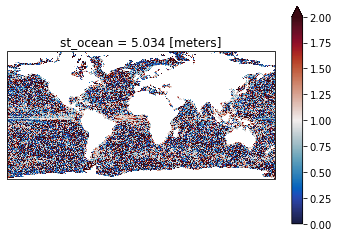

In [40]:
plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()})
test.plot(vmin=0, vmax=2, cmap=cmo.balance, transform=ccrs.PlateCarree())